In [1]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
# 현재 최대 행/열 출력 제한 확인
print(f"현재 최대 행 수: {pd.get_option('display.max_rows')}")
print(f"현재 최대 열 수: {pd.get_option('display.max_columns')}")

# 제한 없이 출력하도록 설정 변경 (None은 제한 없음을 의미)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # 컬럼 너비 제한 해제

현재 최대 행 수: 100
현재 최대 열 수: None


In [3]:
# 데이터 로드
user_df = pd.read_csv('../../data/processed/01_user_profile_preprocessed_v2.csv')
event_df = pd.read_csv('../../data/processed/02_event_log_preprocessed_v2.csv')

print("="*60)
print("데이터 로드 완료!")
print("="*60)
print(f"\nuser_df: {user_df.shape}")
print(f"event_df: {event_df.shape}")


데이터 로드 완료!

user_df: (12500, 23)
event_df: (1757262, 17)


In [4]:
# ============================================================
# 컬럼명/날짜 파생컬럼 확인 및 보정
# ============================================================

# 날짜 컬럼 datetime 변환
event_df["event_time"] = pd.to_datetime(event_df["event_time"], errors="coerce")

# event_month 컬럼이 없으면 event_time에서 생성
if "event_month" not in event_df.columns:
    event_df["event_month"] = event_df["event_time"].dt.to_period("M").astype(str)

# event_weekday 컬럼이 없으면 생성
weekday_map = {
    0: "월",
    1: "화",
    2: "수",
    3: "목",
    4: "금",
    5: "토",
    6: "일"
}

if "event_weekday" not in event_df.columns:
    event_df["event_weekday"] = event_df["event_time"].dt.dayofweek.map(weekday_map)

# event_hour 컬럼이 없으면 생성
if "event_hour" not in event_df.columns:
    event_df["event_hour"] = event_df["event_time"].dt.hour

# 로그 장애 기간 플래그가 없으면 생성
if "is_log_issue_period" not in event_df.columns:
    LOG_ISSUE_START = pd.Timestamp("2025-03-10")
    LOG_ISSUE_END = pd.Timestamp("2025-03-14 23:59:59")
    event_df["is_log_issue_period"] = event_df["event_time"].between(
        LOG_ISSUE_START,
        LOG_ISSUE_END
    )

print("event_df 주요 컬럼 확인:")
print([col for col in ["user_id", "event_time", "event_type", "event_month", "event_weekday", "event_hour", "is_log_issue_period"] if col in event_df.columns])


event_df 주요 컬럼 확인:
['user_id', 'event_time', 'event_type', 'event_month', 'event_weekday', 'event_hour', 'is_log_issue_period']


---
# d30 미잔존 유저는 언제 떠나는가

In [5]:
# 0. 기본 설정

u = user_df.copy()
e = event_df.copy()

u["signup_date"] = pd.to_datetime(u["signup_date"]).dt.normalize()
e["event_time"] = pd.to_datetime(e["event_time"])

if "event_date" not in e.columns:
    e["event_date"] = e["event_time"].dt.normalize()
else:
    e["event_date"] = pd.to_datetime(e["event_date"]).dt.normalize()

# 로그 장애 기간 제외
if "is_log_issue_period" in e.columns:
    e_valid = e[~e["is_log_issue_period"].fillna(False)].copy()
else:
    e_valid = e.copy()

# 알림 이벤트 제외한 앱 내 행동 정의
notification_events = ["알림수신", "알림오픈"]

e_valid["is_app_event"] = (
    e_valid["event_type"].notna()
    & ~e_valid["event_type"].isin(notification_events)
)

app_event = e_valid[e_valid["is_app_event"]].copy()

print("전체 이벤트 수:", len(e))
print("유효 이벤트 수:", len(e_valid))
print("앱 내 행동 이벤트 수:", len(app_event))

전체 이벤트 수: 1757262
유효 이벤트 수: 1736400
앱 내 행동 이벤트 수: 1497204


In [6]:
# d30_observable, d30_retained 생성

log_end_date = e_valid["event_time"].max().normalize()

if "d30_observable" not in u.columns:
    u["d30_date"] = u["signup_date"] + pd.Timedelta(days=30)
    u["d30_observable"] = u["d30_date"] <= log_end_date
else:
    if "d30_date" not in u.columns:
        u["d30_date"] = u["signup_date"] + pd.Timedelta(days=30)

if "d30_retained" not in u.columns:
    d30_app = app_event.merge(
        u[["user_id", "d30_date"]],
        on="user_id",
        how="inner"
    )

    d30_app = d30_app[
        d30_app["event_date"] == d30_app["d30_date"]
    ]

    d30_count = (
        d30_app
        .groupby("user_id")
        .size()
        .rename("d30_app_event_count")
        .reset_index()
    )

    u = u.merge(d30_count, on="user_id", how="left")
    u["d30_app_event_count"] = u["d30_app_event_count"].fillna(0).astype(int)
    u["d30_retained"] = u["d30_observable"] & (u["d30_app_event_count"] > 0)

# D30 관측 가능한 유저만
base = u[u["d30_observable"] == True].copy()

print("D30 관측 가능 유저 수:", len(base))
print("D30 리텐션율:")
display(base["d30_retained"].value_counts(normalize=True))
display(base["d30_retained"].value_counts())

D30 관측 가능 유저 수: 12500
D30 리텐션율:


d30_retained
False    0.76408
True     0.23592
Name: proportion, dtype: float64

d30_retained
False    9551
True     2949
Name: count, dtype: int64

In [7]:
# =========================
# 사용자별 마지막 앱 내 활동
# =========================

last_activity = (
    app_event
    .groupby("user_id")
    .agg(
        last_app_event_time=("event_time", "max"),
        last_app_event_date=("event_date", "max"),
        app_event_count=("event_type", "size"),
        active_days=("event_date", "nunique"),
        session_count=("session_id", "nunique")
    )
    .reset_index()
)

base = base.merge(last_activity, on="user_id", how="left")

# 앱 내 행동이 아예 없는 유저 처리
base["has_app_event"] = base["last_app_event_time"].notna()

# 가입 후 마지막 활동까지 며칠 걸렸는지
base["last_active_day_from_signup"] = (
    base["last_app_event_date"] - base["signup_date"]
).dt.days

# 앱 내 행동 없는 유저는 -1로 표시
base["last_active_day_from_signup"] = base["last_active_day_from_signup"].fillna(-1).astype(int)

# 보기 편한 이탈 시점 구간
bins = [-2, -1, 0, 1, 3, 7, 14, 29, 999]
labels = [
    "앱내행동없음",
    "가입당일_이탈",
    "1일차_이탈",
    "2-3일차_이탈",
    "4-7일차_이탈",
    "8-14일차_이탈",
    "15-29일차_이탈",
    "30일이후_활동"
]

base["last_active_period"] = pd.cut(
    base["last_active_day_from_signup"],
    bins=bins,
    labels=labels
)

display(base[[
    "user_id",
    "signup_date",
    "d30_retained",
    "has_app_event",
    "last_app_event_date",
    "last_active_day_from_signup",
    "last_active_period",
    "app_event_count",
    "active_days",
    "session_count"
]].head())

,user_id,signup_date,d30_retained,has_app_event,last_app_event_date,last_active_day_from_signup,last_active_period,app_event_count,active_days,session_count
0,U0000001,2025-01-25,True,True,2025-04-24,89,30일이후_활동,416.0,79.0,198.0
1,U0000002,2025-05-06,False,True,2025-05-16,10,8-14일차_이탈,53.0,10.0,20.0
2,U0000003,2025-05-14,False,True,2025-05-14,0,가입당일_이탈,3.0,1.0,2.0
3,U0000004,2025-02-23,True,True,2025-03-25,30,30일이후_활동,65.0,18.0,36.0
4,U0000005,2025-02-18,True,True,2025-05-18,89,30일이후_활동,353.0,82.0,185.0


In [8]:
# D30 미잔존 유저만
non_retained = base[base["d30_retained"] == False].copy()

print("D30 미잔존 유저 수:", len(non_retained))

print("\n[D30 미잔존 유저의 마지막 활동 시점 분포]")
display(
    non_retained["last_active_period"]
    .value_counts(dropna=False)
    .rename_axis("last_active_period")
    .reset_index(name="user_count")
)

print("\n[D30 미잔존 유저의 마지막 활동일 요약]")
display(non_retained["last_active_day_from_signup"].describe())

D30 미잔존 유저 수: 9551

[D30 미잔존 유저의 마지막 활동 시점 분포]


,last_active_period,user_count
0,4-7일차_이탈,1991
1,가입당일_이탈,1833
2,8-14일차_이탈,1505
3,2-3일차_이탈,1341
4,30일이후_활동,1125
5,15-29일차_이탈,883
6,1일차_이탈,771
7,앱내행동없음,102



[D30 미잔존 유저의 마지막 활동일 요약]


count    9551.000000
mean       14.540990
std        25.514836
min        -1.000000
25%         1.000000
50%         5.000000
75%        12.000000
max        89.000000
Name: last_active_day_from_signup, dtype: float64

- 평균 14.5일
- 중앙값 5일

---
d30 미잔존 유저의 두가지 유형
- d30 이전에 이탈형
- d30 당일 미활동 후 재방문형


In [9]:
# D30 미잔존 유저를 D30 이전 이탈형 / D30 이후 재방문형으로 분리

non_retained = base[base["d30_retained"] == False].copy()

conditions = [
    non_retained["last_active_day_from_signup"] == -1,
    non_retained["last_active_day_from_signup"].between(0, 29),
    non_retained["last_active_day_from_signup"] == 30,
    non_retained["last_active_day_from_signup"].between(31, 89)
]

choices = [
    "앱내행동없음",
    "D30이전_이탈형",
    "D30당일_활동있음_확인필요",
    "D30이후_재방문형"
]

non_retained["non_retained_type"] = np.select(
    conditions,
    choices,
    default="기타"
)

type_summary = (
    non_retained
    .groupby("non_retained_type")
    .agg(
        user_count=("user_id", "nunique"),
        last_day_mean=("last_active_day_from_signup", "mean"),
        last_day_median=("last_active_day_from_signup", "median")
    )
    .reset_index()
)

type_summary["user_ratio_pct"] = (
    type_summary["user_count"] / type_summary["user_count"].sum() * 100
).round(1)

display(type_summary.sort_values("user_count", ascending=False))

,non_retained_type,user_count,last_day_mean,last_day_median,user_ratio_pct
0,D30이전_이탈형,8324,5.771144,4.0,87.2
1,D30이후_재방문형,1125,80.839111,89.0,11.8
2,앱내행동없음,102,-1.000000,-1.0,1.1


In [10]:
# =========================
# D30 리텐션 개선 타겟:
# D30 이전에 마지막 활동이 끝난 유저
# =========================

pre_d30_churn = non_retained[
    non_retained["non_retained_type"].isin(["앱내행동없음", "D30이전_이탈형"])
].copy()

print("D30 이전 이탈형 유저 수:", len(pre_d30_churn))
print("D30 미잔존 유저 중 비중:")
print(round(len(pre_d30_churn) / len(non_retained) * 100, 1), "%")

display(pre_d30_churn["last_active_day_from_signup"].describe())

D30 이전 이탈형 유저 수: 8426
D30 미잔존 유저 중 비중:
88.2 %


count    8426.000000
mean        5.689176
std         6.195442
min        -1.000000
25%         1.000000
50%         4.000000
75%         8.000000
max        29.000000
Name: last_active_day_from_signup, dtype: float64

In [11]:
# =========================
# D30 이전 이탈형의 이탈 시점 구간
# =========================

bins = [-2, -1, 0, 1, 3, 7, 14, 21, 29]
labels = [
    "앱내행동없음",
    "가입당일_이탈",
    "1일차_이탈",
    "2-3일차_이탈",
    "4-7일차_이탈",
    "8-14일차_이탈",
    "15-21일차_이탈",
    "22-29일차_이탈"
]

pre_d30_churn["pre_d30_churn_period"] = pd.cut(
    pre_d30_churn["last_active_day_from_signup"],
    bins=bins,
    labels=labels
)

churn_period_summary = (
    pre_d30_churn["pre_d30_churn_period"]
    .value_counts()
    .reindex(labels)
    .rename_axis("pre_d30_churn_period")
    .reset_index(name="user_count")
)

churn_period_summary["user_ratio_pct"] = (
    churn_period_summary["user_count"] / churn_period_summary["user_count"].sum() * 100
).round(1)

display(churn_period_summary)

,pre_d30_churn_period,user_count,user_ratio_pct
0,앱내행동없음,102,1.2
1,가입당일_이탈,1833,21.8
2,1일차_이탈,771,9.2
3,2-3일차_이탈,1341,15.9
4,4-7일차_이탈,1991,23.6
5,8-14일차_이탈,1505,17.9
6,15-21일차_이탈,612,7.3
7,22-29일차_이탈,271,3.2


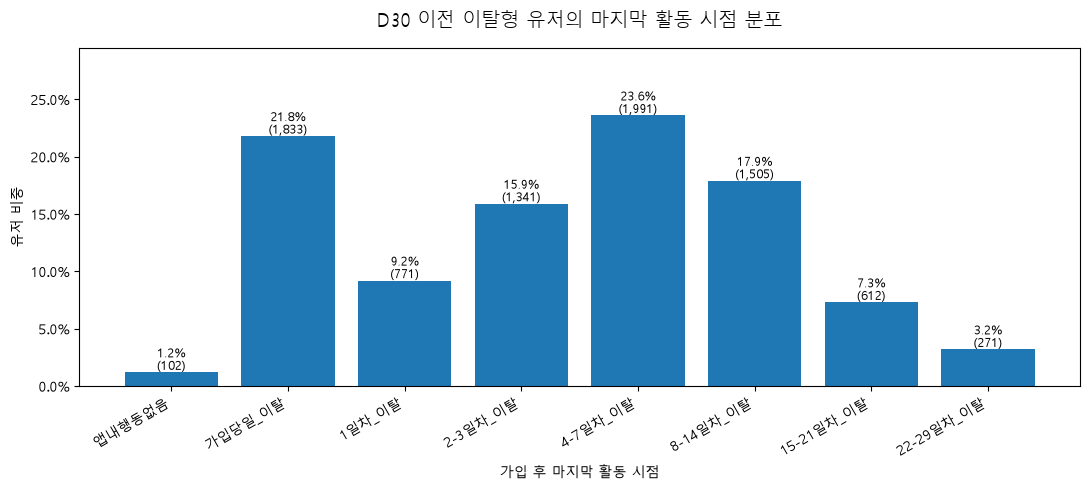

In [13]:
from matplotlib.ticker import PercentFormatter

# 순서 고정
period_order = [
    "앱내행동없음",
    "가입당일_이탈",
    "1일차_이탈",
    "2-3일차_이탈",
    "4-7일차_이탈",
    "8-14일차_이탈",
    "15-21일차_이탈",
    "22-29일차_이탈"
]

plot_df = churn_period_summary.copy()
plot_df["pre_d30_churn_period"] = pd.Categorical(
    plot_df["pre_d30_churn_period"],
    categories=period_order,
    ordered=True
)

plot_df = plot_df.sort_values("pre_d30_churn_period").reset_index(drop=True)

# 비중을 0~1 값으로 변환
plot_df["user_ratio"] = plot_df["user_ratio_pct"] / 100

plt.figure(figsize=(11, 5))

bars = plt.bar(
    plot_df["pre_d30_churn_period"].astype(str),
    plot_df["user_ratio"]
)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.title("D30 이전 이탈형 유저의 마지막 활동 시점 분포", fontsize=14, pad=15)
plt.xlabel("가입 후 마지막 활동 시점")
plt.ylabel("유저 비중")

plt.xticks(rotation=30, ha="right")

# 막대 위 라벨
for bar, pct, count in zip(bars, plot_df["user_ratio_pct"], plot_df["user_count"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{pct:.1f}%\n({count:,})",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.ylim(0, plot_df["user_ratio"].max() * 1.25)
plt.tight_layout()
plt.show()

1~2주 안에 이탈을 붙잡아야함
d7안에 푸시를 보내는 쪽으로

In [14]:
cumulative_df = plot_df.copy()

cumulative_df["cum_user_count"] = cumulative_df["user_count"].cumsum()
cumulative_df["cum_user_ratio_pct"] = (
    cumulative_df["cum_user_count"] / cumulative_df["user_count"].sum() * 100
).round(1)

display(cumulative_df[[
    "pre_d30_churn_period",
    "user_count",
    "user_ratio_pct",
    "cum_user_count",
    "cum_user_ratio_pct"
]])

,pre_d30_churn_period,user_count,user_ratio_pct,cum_user_count,cum_user_ratio_pct
0,앱내행동없음,102,1.2,102,1.2
1,가입당일_이탈,1833,21.8,1935,23.0
2,1일차_이탈,771,9.2,2706,32.1
3,2-3일차_이탈,1341,15.9,4047,48.0
4,4-7일차_이탈,1991,23.6,6038,71.7
5,8-14일차_이탈,1505,17.9,7543,89.5
6,15-21일차_이탈,612,7.3,8155,96.8
7,22-29일차_이탈,271,3.2,8426,100.0


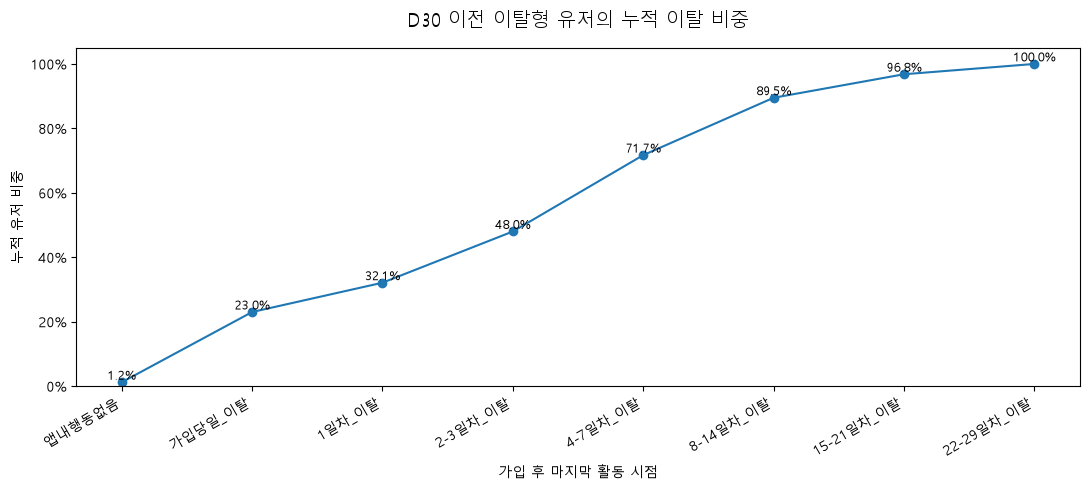

In [15]:
plt.figure(figsize=(11, 5))

plt.plot(
    cumulative_df["pre_d30_churn_period"].astype(str),
    cumulative_df["cum_user_ratio_pct"] / 100,
    marker="o"
)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.title("D30 이전 이탈형 유저의 누적 이탈 비중", fontsize=14, pad=15)
plt.xlabel("가입 후 마지막 활동 시점")
plt.ylabel("누적 유저 비중")

plt.xticks(rotation=30, ha="right")

for x, y, pct in zip(
    cumulative_df["pre_d30_churn_period"].astype(str),
    cumulative_df["cum_user_ratio_pct"] / 100,
    cumulative_df["cum_user_ratio_pct"]
):
    plt.text(x, y, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [16]:
# 마지막 활동 이후 알림을 받았는지

# 마지막 활동 이후 알림 분석 대상

notification_events = ["알림수신", "알림오픈"]

NOTI_RECEIVE = "알림수신"
NOTI_OPEN = "알림오픈"
CHALLENGE_NOTI = "챌린지_알림"

# 마지막 앱 내 행동이 있는 유저만
churn_noti_base = pre_d30_churn[
    pre_d30_churn["has_app_event"] == True
].copy()

# D30 당일 끝까지를 관찰 상한으로 둠
# D30 리텐션 여부와 연결할 때, D30 이후 알림까지 보면 안 되기 때문
churn_noti_base["d30_end_time"] = (
    churn_noti_base["d30_date"] + pd.Timedelta(days=1)
)

print("D30 이전 이탈형 전체:", len(pre_d30_churn))
print("마지막 앱 내 행동이 있는 유저:", len(churn_noti_base))
print("앱내행동없음으로 제외된 유저:", len(pre_d30_churn) - len(churn_noti_base))

D30 이전 이탈형 전체: 8426
마지막 앱 내 행동이 있는 유저: 8324
앱내행동없음으로 제외된 유저: 102


In [17]:
# 마지막 앱 내 행동 이후 발생한 알림 로그

noti_logs = e_valid[
    e_valid["event_type"].isin(notification_events)
].copy()

noti_after_last = noti_logs.merge(
    churn_noti_base[[
        "user_id",
        "last_app_event_time",
        "d30_end_time",
        "pre_d30_churn_period"
    ]],
    on="user_id",
    how="inner"
)

# 마지막 앱 내 행동 이후 ~ D30 당일까지의 알림만
noti_after_last = noti_after_last[
    (noti_after_last["event_time"] > noti_after_last["last_app_event_time"])
    & (noti_after_last["event_time"] < noti_after_last["d30_end_time"])
].copy()

print("마지막 활동 이후 ~ D30 당일까지 알림 로그 수:", len(noti_after_last))

display(
    noti_after_last[[
        "user_id",
        "last_app_event_time",
        "event_time",
        "event_type",
        "notification_type",
        "pre_d30_churn_period"
    ]].head()
)

마지막 활동 이후 ~ D30 당일까지 알림 로그 수: 1776


,user_id,last_app_event_time,event_time,event_type,notification_type,pre_d30_churn_period
67,U0000032,2025-06-06 11:23:43,2025-06-06 15:39:00,알림수신,광고성,8-14일차_이탈
116,U0000049,2025-01-30 09:26:39,2025-01-30 11:00:00,알림수신,리마인드,8-14일차_이탈
117,U0000054,2025-02-17 22:36:05,2025-03-01 11:03:00,알림수신,광고성,4-7일차_이탈
141,U0000058,2025-02-02 07:54:39,2025-02-02 17:31:00,알림수신,챌린지_알림,가입당일_이탈
149,U0000063,2025-03-01 12:12:32,2025-03-09 14:52:00,알림수신,리마인드,8-14일차_이탈


In [18]:
#  마지막 활동 후 N일 내 알림 피처 생성

def make_after_last_noti_features(days):
    tmp = noti_after_last[
        noti_after_last["event_time"]
        <= noti_after_last["last_app_event_time"] + pd.Timedelta(days=days)
    ].copy()

    tmp["is_receive"] = tmp["event_type"].eq(NOTI_RECEIVE)
    tmp["is_open"] = tmp["event_type"].eq(NOTI_OPEN)

    tmp["is_challenge_receive"] = (
        tmp["notification_type"].eq(CHALLENGE_NOTI)
        & tmp["event_type"].eq(NOTI_RECEIVE)
    )

    tmp["is_challenge_open"] = (
        tmp["notification_type"].eq(CHALLENGE_NOTI)
        & tmp["event_type"].eq(NOTI_OPEN)
    )

    tmp["is_remind_receive"] = (
        tmp["notification_type"].eq("리마인드")
        & tmp["event_type"].eq(NOTI_RECEIVE)
    )

    tmp["is_remind_open"] = (
        tmp["notification_type"].eq("리마인드")
        & tmp["event_type"].eq(NOTI_OPEN)
    )

    tmp["is_ad_receive"] = (
        tmp["notification_type"].eq("광고성")
        & tmp["event_type"].eq(NOTI_RECEIVE)
    )

    tmp["is_ad_open"] = (
        tmp["notification_type"].eq("광고성")
        & tmp["event_type"].eq(NOTI_OPEN)
    )

    agg = (
        tmp
        .groupby("user_id")
        .agg(
            receive_count=("is_receive", "sum"),
            open_count=("is_open", "sum"),
            challenge_receive_count=("is_challenge_receive", "sum"),
            challenge_open_count=("is_challenge_open", "sum"),
            remind_receive_count=("is_remind_receive", "sum"),
            remind_open_count=("is_remind_open", "sum"),
            ad_receive_count=("is_ad_receive", "sum"),
            ad_open_count=("is_ad_open", "sum")
        )
        .reset_index()
    )

    prefix = f"after_last_{days}d"

    rename_dict = {
        col: f"{prefix}_{col}"
        for col in agg.columns
        if col != "user_id"
    }

    agg = agg.rename(columns=rename_dict)

    return agg


after_noti_features = churn_noti_base[[
    "user_id",
    "pre_d30_churn_period",
    "last_active_day_from_signup",
    "last_app_event_time",
    "d30_date"
]].copy()

for days in [1, 3, 7]:
    feat = make_after_last_noti_features(days)
    after_noti_features = after_noti_features.merge(
        feat,
        on="user_id",
        how="left"
    )

# 결측 0 처리
count_cols = [
    c for c in after_noti_features.columns
    if c.startswith("after_last_") and c.endswith("_count")
]

after_noti_features[count_cols] = (
    after_noti_features[count_cols]
    .fillna(0)
    .astype(int)
)

# 여부형 플래그 생성
for days in [1, 3, 7]:
    prefix = f"after_last_{days}d"

    after_noti_features[f"{prefix}_has_receive"] = (
        after_noti_features[f"{prefix}_receive_count"] > 0
    )

    after_noti_features[f"{prefix}_has_open"] = (
        after_noti_features[f"{prefix}_open_count"] > 0
    )

    after_noti_features[f"{prefix}_received_but_no_open"] = (
        after_noti_features[f"{prefix}_has_receive"]
        & ~after_noti_features[f"{prefix}_has_open"]
    )

    after_noti_features[f"{prefix}_has_challenge_receive"] = (
        after_noti_features[f"{prefix}_challenge_receive_count"] > 0
    )

    after_noti_features[f"{prefix}_has_challenge_open"] = (
        after_noti_features[f"{prefix}_challenge_open_count"] > 0
    )

    after_noti_features[f"{prefix}_challenge_received_but_no_open"] = (
        after_noti_features[f"{prefix}_has_challenge_receive"]
        & ~after_noti_features[f"{prefix}_has_challenge_open"]
    )

display(after_noti_features.head())

,user_id,pre_d30_churn_period,last_active_day_from_signup,last_app_event_time,d30_date,after_last_1d_receive_count,after_last_1d_open_count,after_last_1d_challenge_receive_count,after_last_1d_challenge_open_count,after_last_1d_remind_receive_count,after_last_1d_remind_open_count,after_last_1d_ad_receive_count,after_last_1d_ad_open_count,after_last_3d_receive_count,after_last_3d_open_count,after_last_3d_challenge_receive_count,after_last_3d_challenge_open_count,after_last_3d_remind_receive_count,after_last_3d_remind_open_count,after_last_3d_ad_receive_count,after_last_3d_ad_open_count,after_last_7d_receive_count,after_last_7d_open_count,after_last_7d_challenge_receive_count,after_last_7d_challenge_open_count,after_last_7d_remind_receive_count,after_last_7d_remind_open_count,after_last_7d_ad_receive_count,after_last_7d_ad_open_count,after_last_1d_has_receive,after_last_1d_has_open,after_last_1d_received_but_no_open,after_last_1d_has_challenge_receive,after_last_1d_has_challenge_open,after_last_1d_challenge_received_but_no_open,after_last_3d_has_receive,after_last_3d_has_open,after_last_3d_received_but_no_open,after_last_3d_has_challenge_receive,after_last_3d_has_challenge_open,after_last_3d_challenge_received_but_no_open,after_last_7d_has_receive,after_last_7d_has_open,after_last_7d_received_but_no_open,after_last_7d_has_challenge_receive,after_last_7d_has_challenge_open,after_last_7d_challenge_received_but_no_open
0,U0000002,8-14일차_이탈,10,2025-05-16 21:13:50,2025-06-05,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,U0000003,가입당일_이탈,0,2025-05-14 14:29:31,2025-06-13,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,U0000006,가입당일_이탈,0,2025-02-07 17:56:46,2025-03-09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,U0000007,2-3일차_이탈,2,2025-03-28 20:19:59,2025-04-25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,U0000009,가입당일_이탈,0,2025-05-20 22:45:42,2025-06-19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [19]:
# 마지막 활동 후 알림 반응 전체 요약

summary_rows = []

for days in [1, 3, 7]:
    prefix = f"after_last_{days}d"

    total_user = len(after_noti_features)

    receive_user = after_noti_features[f"{prefix}_has_receive"].sum()
    open_user = after_noti_features[f"{prefix}_has_open"].sum()
    received_no_open_user = after_noti_features[f"{prefix}_received_but_no_open"].sum()

    challenge_receive_user = after_noti_features[f"{prefix}_has_challenge_receive"].sum()
    challenge_open_user = after_noti_features[f"{prefix}_has_challenge_open"].sum()
    challenge_received_no_open_user = after_noti_features[f"{prefix}_challenge_received_but_no_open"].sum()

    summary_rows.append({
        "window": f"마지막 활동 후 {days}일 내",
        "total_user": total_user,

        "알림수신_유저수": receive_user,
        "알림수신율": receive_user / total_user,

        "알림오픈_유저수": open_user,
        "알림오픈율_전체기준": open_user / total_user,
        "알림오픈율_수신자기준": open_user / receive_user if receive_user > 0 else np.nan,

        "수신했지만_미오픈_유저수": received_no_open_user,
        "수신했지만_미오픈율_전체기준": received_no_open_user / total_user,
        "수신했지만_미오픈율_수신자기준": received_no_open_user / receive_user if receive_user > 0 else np.nan,

        "챌린지알림수신_유저수": challenge_receive_user,
        "챌린지알림수신율": challenge_receive_user / total_user,

        "챌린지알림오픈_유저수": challenge_open_user,
        "챌린지알림오픈율_전체기준": challenge_open_user / total_user,
        "챌린지알림오픈율_수신자기준": challenge_open_user / challenge_receive_user if challenge_receive_user > 0 else np.nan,

        "챌린지수신했지만_미오픈_유저수": challenge_received_no_open_user,
        "챌린지수신했지만_미오픈율_수신자기준": challenge_received_no_open_user / challenge_receive_user if challenge_receive_user > 0 else np.nan
    })

after_last_summary = pd.DataFrame(summary_rows)

# 보기 좋게 퍼센트 컬럼 반올림
rate_cols = [c for c in after_last_summary.columns if "율" in c]

after_last_summary_display = after_last_summary.copy()
after_last_summary_display[rate_cols] = (
    after_last_summary_display[rate_cols] * 100
).round(1)

display(after_last_summary_display)

,window,total_user,알림수신_유저수,알림수신율,알림오픈_유저수,알림오픈율_전체기준,알림오픈율_수신자기준,수신했지만_미오픈_유저수,수신했지만_미오픈율_전체기준,수신했지만_미오픈율_수신자기준,챌린지알림수신_유저수,챌린지알림수신율,챌린지알림오픈_유저수,챌린지알림오픈율_전체기준,챌린지알림오픈율_수신자기준,챌린지수신했지만_미오픈_유저수,챌린지수신했지만_미오픈율_수신자기준
0,마지막 활동 후 1일 내,8324,1481,17.8,194,2.3,13.1,1304,15.7,88.0,376,4.5,74,0.9,19.7,311,82.7
1,마지막 활동 후 3일 내,8324,1493,17.9,195,2.3,13.1,1315,15.8,88.1,376,4.5,74,0.9,19.7,311,82.7
2,마지막 활동 후 7일 내,8324,1511,18.2,195,2.3,12.9,1333,16.0,88.2,376,4.5,74,0.9,19.7,311,82.7


In [20]:
# 이탈 시점별 마지막 활동 후 7일 내 알림 반응

period_noti_summary = (
    after_noti_features
    .groupby("pre_d30_churn_period", observed=False)
    .agg(
        user_count=("user_id", "nunique"),

        receive_7d_rate=("after_last_7d_has_receive", "mean"),
        open_7d_rate=("after_last_7d_has_open", "mean"),
        received_but_no_open_7d_rate=("after_last_7d_received_but_no_open", "mean"),

        challenge_receive_7d_rate=("after_last_7d_has_challenge_receive", "mean"),
        challenge_open_7d_rate=("after_last_7d_has_challenge_open", "mean"),
        challenge_received_but_no_open_7d_rate=("after_last_7d_challenge_received_but_no_open", "mean")
    )
    .reset_index()
)

rate_cols = [
    c for c in period_noti_summary.columns
    if c.endswith("_rate")
]

period_noti_summary[rate_cols] = (
    period_noti_summary[rate_cols] * 100
).round(1)

display(period_noti_summary)

,pre_d30_churn_period,user_count,receive_7d_rate,open_7d_rate,received_but_no_open_7d_rate,challenge_receive_7d_rate,challenge_open_7d_rate,challenge_received_but_no_open_7d_rate
0,앱내행동없음,0,NaN,NaN,NaN,NaN,NaN,NaN
1,가입당일_이탈,1833,13.0,2.4,10.8,3.9,1.0,3.0
2,1일차_이탈,771,17.9,1.9,16.2,3.9,0.6,3.4
3,2-3일차_이탈,1341,18.2,2.2,16.3,4.4,0.8,3.8
4,4-7일차_이탈,1991,18.7,2.6,16.4,4.9,1.0,4.0
5,8-14일차_이탈,1505,21.9,2.3,19.6,4.9,0.8,4.2
6,15-21일차_이탈,612,21.7,2.6,19.3,5.7,1.3,4.6
7,22-29일차_이탈,271,20.3,1.5,19.2,3.3,0.0,3.3


1. 마지막 활동 후 7일 내 알림을 받은 유저가 18.2%로 낮다
2. 알림을 받은 유저도 대부분 열지 않는다    
=> 4~7일차에 이탈이 가장 많으니까 3일차쯤에 알림을 보낸다   
이때 알림 반응 가능성이 높은 유저를 선별해 맞춤형으로 보내기

---
### 마지막 활동 전 어떤 활동을 했을까

In [21]:
# 마지막 앱 내 행동의 event_type 찾기

# 마지막 앱 내 행동이 있는 유저만 사용
last_event_base = pre_d30_churn[
    pre_d30_churn["has_app_event"] == True
].copy()

# 앱 내 행동 이벤트만
app_event_for_last = app_event.merge(
    last_event_base[[
        "user_id",
        "last_app_event_time",
        "pre_d30_churn_period"
    ]],
    on="user_id",
    how="inner"
)

# 사용자별 마지막 앱 내 행동과 같은 시각의 이벤트 추출
last_event_logs = app_event_for_last[
    app_event_for_last["event_time"] == app_event_for_last["last_app_event_time"]
].copy()

# 같은 timestamp에 여러 이벤트가 있을 수 있으므로 우선 하나만 남김
last_event_logs = (
    last_event_logs
    .sort_values(["user_id", "event_time"])
    .drop_duplicates("user_id", keep="last")
)

last_event_type = last_event_logs[[
    "user_id",
    "event_type",
    "pre_d30_churn_period",
    "last_app_event_time"
]].rename(columns={
    "event_type": "last_app_event_type"
})

display(last_event_type.head())

,user_id,last_app_event_type,pre_d30_churn_period,last_app_event_time
52,U0000002,수면기록,8-14일차_이탈,2025-05-16 21:13:50
55,U0000003,앱실행,가입당일_이탈,2025-05-14 14:29:31
59,U0000006,운동기록,가입당일_이탈,2025-02-07 17:56:46
89,U0000007,식단기록,2-3일차_이탈,2025-03-28 20:19:59
95,U0000009,앱실행,가입당일_이탈,2025-05-20 22:45:42


In [22]:
# 마지막 행동 유형 전체 분포

last_event_summary = (
    last_event_type
    .groupby("last_app_event_type")
    .agg(user_count=("user_id", "nunique"))
    .reset_index()
    .sort_values("user_count", ascending=False)
)

last_event_summary["user_ratio_pct"] = (
    last_event_summary["user_count"] / last_event_summary["user_count"].sum() * 100
).round(1)

display(last_event_summary)

,last_app_event_type,user_count,user_ratio_pct
3,앱실행,2855,34.3
1,수면기록,1312,15.8
7,챌린지참여,1307,15.7
0,마음챙김,1030,12.4
2,식단기록,958,11.5
5,운동기록,786,9.4
4,온보딩_완료,56,0.7
6,챌린지_탐색,20,0.2


In [23]:
# 이탈 구간별 마지막 행동 유형

period_last_event = (
    last_event_type
    .groupby(["pre_d30_churn_period", "last_app_event_type"], observed=False)
    .agg(user_count=("user_id", "nunique"))
    .reset_index()
)

period_total = (
    last_event_type
    .groupby("pre_d30_churn_period", observed=False)
    .agg(total_user=("user_id", "nunique"))
    .reset_index()
)

period_last_event = period_last_event.merge(
    period_total,
    on="pre_d30_churn_period",
    how="left"
)

period_last_event["ratio_pct"] = (
    period_last_event["user_count"] / period_last_event["total_user"] * 100
).round(1)

period_last_event = period_last_event.sort_values(
    ["pre_d30_churn_period", "user_count"],
    ascending=[True, False]
)

display(period_last_event)

,pre_d30_churn_period,last_app_event_type,user_count,total_user,ratio_pct
0,앱내행동없음,마음챙김,0,0,NaN
1,앱내행동없음,수면기록,0,0,NaN
2,앱내행동없음,식단기록,0,0,NaN
3,앱내행동없음,앱실행,0,0,NaN
4,앱내행동없음,온보딩_완료,0,0,NaN
5,앱내행동없음,운동기록,0,0,NaN
6,앱내행동없음,챌린지_탐색,0,0,NaN
7,앱내행동없음,챌린지참여,0,0,NaN
11,가입당일_이탈,앱실행,508,1833,27.7
15,가입당일_이탈,챌린지참여,432,1833,23.6


In [24]:
# 이탈 구간별 Top 3 마지막 행동

top3_last_event_by_period = (
    period_last_event
    .sort_values(["pre_d30_churn_period", "user_count"], ascending=[True, False])
    .groupby("pre_d30_churn_period", observed=False)
    .head(3)
    .reset_index(drop=True)
)

display(top3_last_event_by_period)

,pre_d30_churn_period,last_app_event_type,user_count,total_user,ratio_pct
0,앱내행동없음,마음챙김,0,0,NaN
1,앱내행동없음,수면기록,0,0,NaN
2,앱내행동없음,식단기록,0,0,NaN
3,가입당일_이탈,앱실행,508,1833,27.7
4,가입당일_이탈,챌린지참여,432,1833,23.6
5,가입당일_이탈,수면기록,261,1833,14.2
6,1일차_이탈,앱실행,262,771,34.0
7,1일차_이탈,수면기록,119,771,15.4
8,1일차_이탈,마음챙김,103,771,13.4
9,2-3일차_이탈,앱실행,478,1341,35.6


In [26]:
# 마지막 행동 유형별 알림 반응

last_event_noti = last_event_type.merge(
    after_noti_features,
    on="user_id",
    how="left"
)

last_event_noti_summary = (
    last_event_noti
    .groupby("last_app_event_type")
    .agg(
        user_count=("user_id", "nunique"),
        receive_7d_rate=("after_last_7d_has_receive", "mean"),
        open_7d_rate=("after_last_7d_has_open", "mean"),
        received_but_no_open_7d_rate=("after_last_7d_received_but_no_open", "mean"),
        challenge_receive_7d_rate=("after_last_7d_has_challenge_receive", "mean"),
        challenge_open_7d_rate=("after_last_7d_has_challenge_open", "mean"),
        challenge_received_but_no_open_7d_rate=("after_last_7d_challenge_received_but_no_open", "mean")
    )
    .reset_index()
    .sort_values("user_count", ascending=False)
)

rate_cols = [c for c in last_event_noti_summary.columns if c.endswith("_rate")]
last_event_noti_summary[rate_cols] = (
    last_event_noti_summary[rate_cols] * 100
).round(1)

display(last_event_noti_summary)

,last_app_event_type,user_count,receive_7d_rate,open_7d_rate,received_but_no_open_7d_rate,challenge_receive_7d_rate,challenge_open_7d_rate,challenge_received_but_no_open_7d_rate
3,앱실행,2855,18.5,2.5,16.3,4.8,0.8,4.1
1,수면기록,1312,19.0,2.1,17.0,3.7,0.8,3.0
7,챌린지참여,1307,16.1,1.9,14.4,4.3,0.8,3.6
0,마음챙김,1030,15.9,2.2,13.9,3.9,0.8,3.2
2,식단기록,958,20.1,3.1,17.1,5.6,1.4,4.3
5,운동기록,786,19.1,2.2,17.0,4.6,1.1,3.6
4,온보딩_완료,56,17.9,1.8,17.9,7.1,0.0,7.1
6,챌린지_탐색,20,30.0,5.0,25.0,0.0,0.0,0.0


마지막 행동이 무엇이든 마지막 활동 후 알림을 받은 비율 자체가 낮고 받은 유저도 대부분 열지 않음     
다만 바로 챌린지로 유도하는 것은 위험   
    애초에 챌린지 참여 자체가 고관여유저이기 때문   
마지막 행동이 기록 기능인 유저에게는 관련 챌린지를 추천하고     
앱실행인 유저는 챌린지보다 기록 리마인드로 연결되게

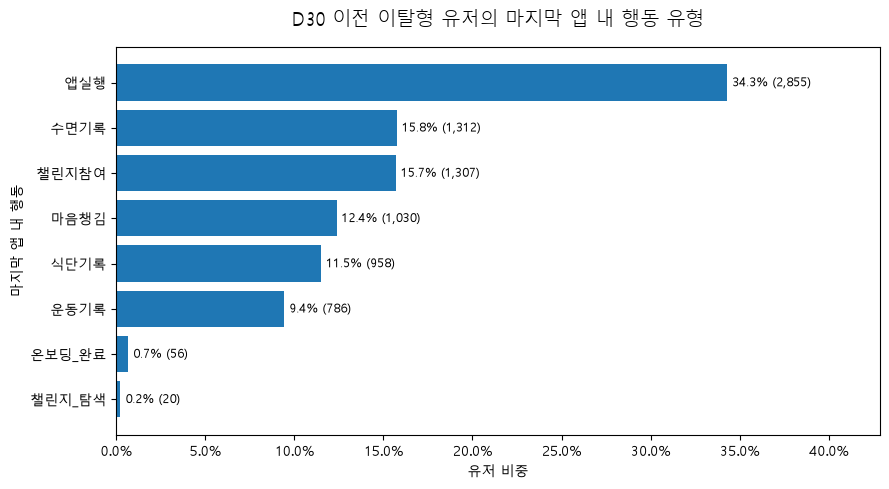

In [28]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plot_df = last_event_noti_summary.copy()

# 유저 수 기준 정렬
plot_df = plot_df.sort_values("user_count", ascending=True)

total_user = plot_df["user_count"].sum()
plot_df["user_ratio"] = plot_df["user_count"] / total_user

plt.figure(figsize=(9, 5))

bars = plt.barh(
    plot_df["last_app_event_type"],
    plot_df["user_ratio"]
)

plt.gca().xaxis.set_major_formatter(PercentFormatter(1))

plt.title("D30 이전 이탈형 유저의 마지막 앱 내 행동 유형", fontsize=14, pad=15)
plt.xlabel("유저 비중")
plt.ylabel("마지막 앱 내 행동")

for bar, pct, count in zip(bars, plot_df["user_ratio"], plot_df["user_count"]):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {pct*100:.1f}% ({count:,})",
        va="center",
        fontsize=9
    )

plt.xlim(0, plot_df["user_ratio"].max() * 1.25)
plt.tight_layout()
plt.show()

마지막 행동 1위 앱실행  
= 앱만 실행하고 사라짐  
=> 앱 진입 후 첫 화면/추천 카드/cta 가 다음 행동을 충분히 유도하지 못했을 가능성

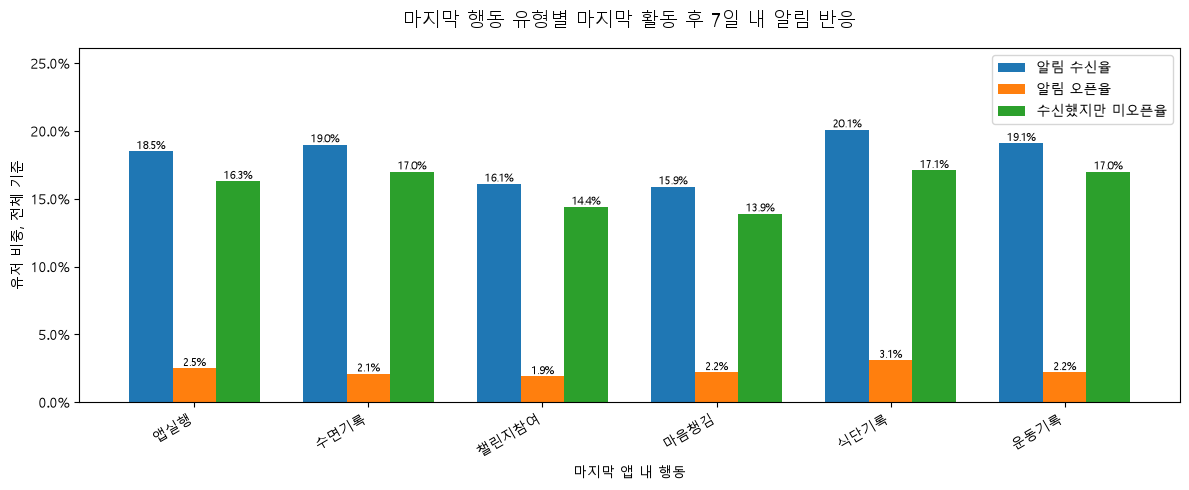

In [ ]:
# =========================
# 마지막 행동 유형별 알림 수신/오픈/미오픈율 시각화
# =========================

plot_df = last_event_noti_summary.copy()

# 표본이 너무 작은 유형은 제외
# 필요하면 100을 0으로 바꾸면 전체 유형이 다 나옴
plot_df = plot_df[plot_df["user_count"] >= 100].copy()

# 유저 수 많은 순서로 정렬
plot_df = plot_df.sort_values("user_count", ascending=False).reset_index(drop=True)

# 혹시 비율이 0~1로 들어간 경우 자동 보정
rate_cols = [
    "receive_7d_rate",
    "open_7d_rate",
    "received_but_no_open_7d_rate"
]

for col in rate_cols:
    if plot_df[col].max() <= 1:
        plot_df[col] = plot_df[col] * 100

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(12, 5))

bars1 = plt.bar(
    x - width,
    plot_df["receive_7d_rate"] / 100,
    width,
    label="알림 수신율"
)

bars2 = plt.bar(
    x,
    plot_df["open_7d_rate"] / 100,
    width,
    label="알림 오픈율"
)

bars3 = plt.bar(
    x + width,
    plot_df["received_but_no_open_7d_rate"] / 100,
    width,
    label="수신했지만 미오픈율"
)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.title("마지막 행동 유형별 마지막 활동 후 7일 내 알림 반응", fontsize=14, pad=15)
plt.xlabel("마지막 앱 내 행동")
plt.ylabel("유저 비중, 전체 기준")

plt.xticks(x, plot_df["last_app_event_type"], rotation=30, ha="right")
plt.legend()

# 막대 위 라벨
for bars, col in zip(
    [bars1, bars2, bars3],
    ["receive_7d_rate", "open_7d_rate", "received_but_no_open_7d_rate"]
):
    for bar, value in zip(bars, plot_df[col]):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

ymax = plot_df[rate_cols].max().max() / 100
plt.ylim(0, ymax * 1.3)

plt.tight_layout()
plt.show()

In [36]:

NOTI_RECEIVE = "알림수신"
NOTI_OPEN = "알림오픈"

notification_types = ["리마인드", "챌린지_알림", "광고성"]

# =========================
# 1. 마지막 행동 유저 베이스
# =========================

last_action_base = last_event_type[[
    "user_id",
    "last_app_event_type",
    "last_app_event_time"
]].copy()

# d30_date 붙이기
last_action_base = last_action_base.merge(
    pre_d30_churn[["user_id", "d30_date"]],
    on="user_id",
    how="left"
)

# 마지막 활동 후 7일, 단 D30 이후 정보는 보지 않도록 제한
last_action_base["after_7d_end_time"] = (
    last_action_base["last_app_event_time"] + pd.Timedelta(days=7)
)

last_action_base["d30_end_time"] = (
    last_action_base["d30_date"] + pd.Timedelta(days=1)
)

last_action_base["window_end_time"] = last_action_base[
    ["after_7d_end_time", "d30_end_time"]
].min(axis=1)


# =========================
# 2. 마지막 활동 후 7일 내 알림 로그 추출
# =========================

noti_logs = e_valid[
    e_valid["event_type"].isin([NOTI_RECEIVE, NOTI_OPEN])
].copy()

noti_7d_by_last_action = noti_logs.merge(
    last_action_base,
    on="user_id",
    how="inner"
)

noti_7d_by_last_action = noti_7d_by_last_action[
    (noti_7d_by_last_action["event_time"] > noti_7d_by_last_action["last_app_event_time"])
    & (noti_7d_by_last_action["event_time"] < noti_7d_by_last_action["window_end_time"])
].copy()

# 알림 유형이 명확한 것만 사용
noti_7d_by_last_action = noti_7d_by_last_action[
    noti_7d_by_last_action["notification_type"].isin(notification_types)
].copy()

display(noti_7d_by_last_action[[
    "user_id",
    "last_app_event_type",
    "last_app_event_time",
    "event_time",
    "event_type",
    "notification_type"
]].head())

,user_id,last_app_event_type,last_app_event_time,event_time,event_type,notification_type
67,U0000032,식단기록,2025-06-06 11:23:43,2025-06-06 15:39:00,알림수신,광고성
116,U0000049,앱실행,2025-01-30 09:26:39,2025-01-30 11:00:00,알림수신,리마인드
141,U0000058,수면기록,2025-02-02 07:54:39,2025-02-02 17:31:00,알림수신,챌린지_알림
159,U0000068,챌린지참여,2025-02-06 12:25:10,2025-02-06 20:10:00,알림수신,챌린지_알림
187,U0000078,수면기록,2025-05-02 07:07:17,2025-05-02 15:50:00,알림수신,리마인드


In [37]:
# =========================
# 마지막 행동 유형별 전체 유저 수
# =========================

last_action_denominator = (
    last_action_base
    .groupby("last_app_event_type")
    .agg(last_action_user_count=("user_id", "nunique"))
    .reset_index()
)

# =========================
# 알림 유형별 수신 유저 수
# =========================

receive_user = (
    noti_7d_by_last_action[
        noti_7d_by_last_action["event_type"] == NOTI_RECEIVE
    ]
    .groupby(["last_app_event_type", "notification_type"])
    .agg(receive_user_count=("user_id", "nunique"))
    .reset_index()
)

# =========================
# 알림 유형별 오픈 유저 수
# =========================

open_user = (
    noti_7d_by_last_action[
        noti_7d_by_last_action["event_type"] == NOTI_OPEN
    ]
    .groupby(["last_app_event_type", "notification_type"])
    .agg(open_user_count=("user_id", "nunique"))
    .reset_index()
)

# 모든 조합 만들기
all_combo = pd.MultiIndex.from_product(
    [
        last_action_base["last_app_event_type"].dropna().unique(),
        notification_types
    ],
    names=["last_app_event_type", "notification_type"]
).to_frame(index=False)

last_action_noti_type_summary = (
    all_combo
    .merge(last_action_denominator, on="last_app_event_type", how="left")
    .merge(receive_user, on=["last_app_event_type", "notification_type"], how="left")
    .merge(open_user, on=["last_app_event_type", "notification_type"], how="left")
)

last_action_noti_type_summary[["receive_user_count", "open_user_count"]] = (
    last_action_noti_type_summary[["receive_user_count", "open_user_count"]]
    .fillna(0)
    .astype(int)
)

last_action_noti_type_summary["received_but_no_open_user_count"] = (
    last_action_noti_type_summary["receive_user_count"]
    - last_action_noti_type_summary["open_user_count"]
).clip(lower=0)

# =========================
# 비율 계산
# =========================

last_action_noti_type_summary["receive_rate_all"] = (
    last_action_noti_type_summary["receive_user_count"]
    / last_action_noti_type_summary["last_action_user_count"]
)

last_action_noti_type_summary["open_rate_all"] = (
    last_action_noti_type_summary["open_user_count"]
    / last_action_noti_type_summary["last_action_user_count"]
)

last_action_noti_type_summary["received_but_no_open_rate_all"] = (
    last_action_noti_type_summary["received_but_no_open_user_count"]
    / last_action_noti_type_summary["last_action_user_count"]
)

last_action_noti_type_summary["open_rate_receiver"] = np.where(
    last_action_noti_type_summary["receive_user_count"] > 0,
    last_action_noti_type_summary["open_user_count"]
    / last_action_noti_type_summary["receive_user_count"],
    np.nan
)

last_action_noti_type_summary["received_but_no_open_rate_receiver"] = np.where(
    last_action_noti_type_summary["receive_user_count"] > 0,
    last_action_noti_type_summary["received_but_no_open_user_count"]
    / last_action_noti_type_summary["receive_user_count"],
    np.nan
)

# 보기용 테이블
summary_display = last_action_noti_type_summary.copy()

rate_cols = [
    "receive_rate_all",
    "open_rate_all",
    "received_but_no_open_rate_all",
    "open_rate_receiver",
    "received_but_no_open_rate_receiver"
]

summary_display[rate_cols] = (
    summary_display[rate_cols] * 100
).round(1)

summary_display = summary_display.sort_values(
    ["last_action_user_count", "last_app_event_type", "notification_type"],
    ascending=[False, True, True]
)

display(summary_display)

,last_app_event_type,notification_type,last_action_user_count,receive_user_count,open_user_count,received_but_no_open_user_count,receive_rate_all,open_rate_all,received_but_no_open_rate_all,open_rate_receiver,received_but_no_open_rate_receiver
5,앱실행,광고성,2855,146,7,139,5.1,0.2,4.9,4.8,95.2
3,앱실행,리마인드,2855,248,40,208,8.7,1.4,7.3,16.1,83.9
4,앱실행,챌린지_알림,2855,137,23,114,4.8,0.8,4.0,16.8,83.2
2,수면기록,광고성,1312,82,5,77,6.2,0.4,5.9,6.1,93.9
0,수면기록,리마인드,1312,118,12,106,9.0,0.9,8.1,10.2,89.8
1,수면기록,챌린지_알림,1312,49,11,38,3.7,0.8,2.9,22.4,77.6
14,챌린지참여,광고성,1307,71,3,68,5.4,0.2,5.2,4.2,95.8
12,챌린지참여,리마인드,1307,84,12,72,6.4,0.9,5.5,14.3,85.7
13,챌린지참여,챌린지_알림,1307,56,10,46,4.3,0.8,3.5,17.9,82.1
17,마음챙김,광고성,1030,53,2,51,5.1,0.2,5.0,3.8,96.2


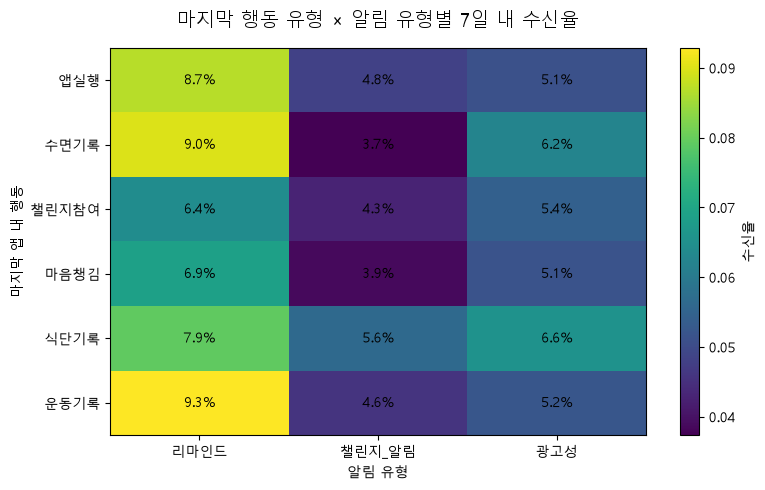

In [39]:
# 표본 작은 마지막 행동 유형 제외
plot_base = last_action_noti_type_summary[
    last_action_noti_type_summary["last_action_user_count"] >= 100
].copy()

# 마지막 행동 유형 순서: 유저 수 많은 순
action_order = (
    plot_base[["last_app_event_type", "last_action_user_count"]]
    .drop_duplicates()
    .sort_values("last_action_user_count", ascending=False)["last_app_event_type"]
    .tolist()
)

noti_order = ["리마인드", "챌린지_알림", "광고성"]

heat_df = (
    plot_base
    .pivot_table(
        index="last_app_event_type",
        columns="notification_type",
        values="receive_rate_all",
        aggfunc="mean"
    )
    .reindex(index=action_order, columns=noti_order)
)

plt.figure(figsize=(8, 5))

im = plt.imshow(
    heat_df.values,
    aspect="auto"
)

plt.colorbar(im, label="수신율")

plt.xticks(
    ticks=np.arange(len(heat_df.columns)),
    labels=heat_df.columns
)

plt.yticks(
    ticks=np.arange(len(heat_df.index)),
    labels=heat_df.index
)

plt.title("마지막 행동 유형 × 알림 유형별 7일 내 수신율", fontsize=14, pad=15)
plt.xlabel("알림 유형")
plt.ylabel("마지막 앱 내 행동")

for i in range(heat_df.shape[0]):
    for j in range(heat_df.shape[1]):
        value = heat_df.iloc[i, j]
        if pd.notna(value):
            plt.text(
                j,
                i,
                f"{value*100:.1f}%",
                ha="center",
                va="center",
                fontsize=10
            )

plt.tight_layout()
plt.show()

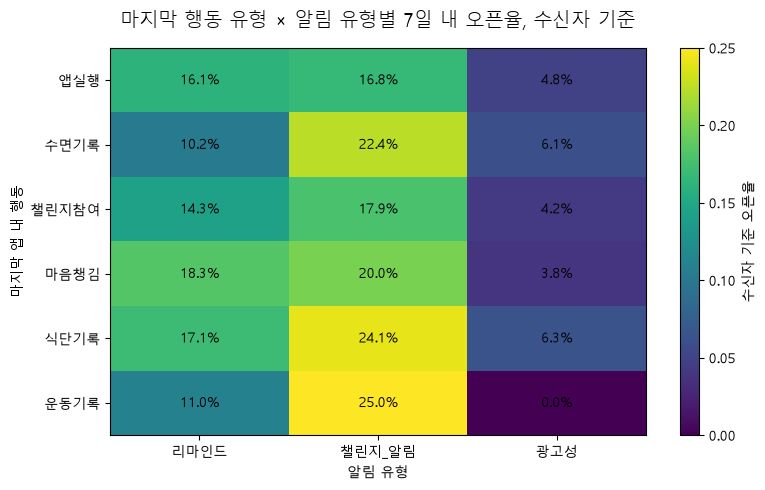

In [40]:
heat_df = (
    plot_base
    .pivot_table(
        index="last_app_event_type",
        columns="notification_type",
        values="open_rate_receiver",
        aggfunc="mean"
    )
    .reindex(index=action_order, columns=noti_order)
)

plt.figure(figsize=(8, 5))

im = plt.imshow(
    heat_df.values,
    aspect="auto"
)

plt.colorbar(im, label="수신자 기준 오픈율")

plt.xticks(
    ticks=np.arange(len(heat_df.columns)),
    labels=heat_df.columns
)

plt.yticks(
    ticks=np.arange(len(heat_df.index)),
    labels=heat_df.index
)

plt.title("마지막 행동 유형 × 알림 유형별 7일 내 오픈율, 수신자 기준", fontsize=14, pad=15)
plt.xlabel("알림 유형")
plt.ylabel("마지막 앱 내 행동")

for i in range(heat_df.shape[0]):
    for j in range(heat_df.shape[1]):
        value = heat_df.iloc[i, j]
        if pd.notna(value):
            plt.text(
                j,
                i,
                f"{value*100:.1f}%",
                ha="center",
                va="center",
                fontsize=10
            )
        else:
            plt.text(
                j,
                i,
                "-",
                ha="center",
                va="center",
                fontsize=10
            )

plt.tight_layout()
plt.show()

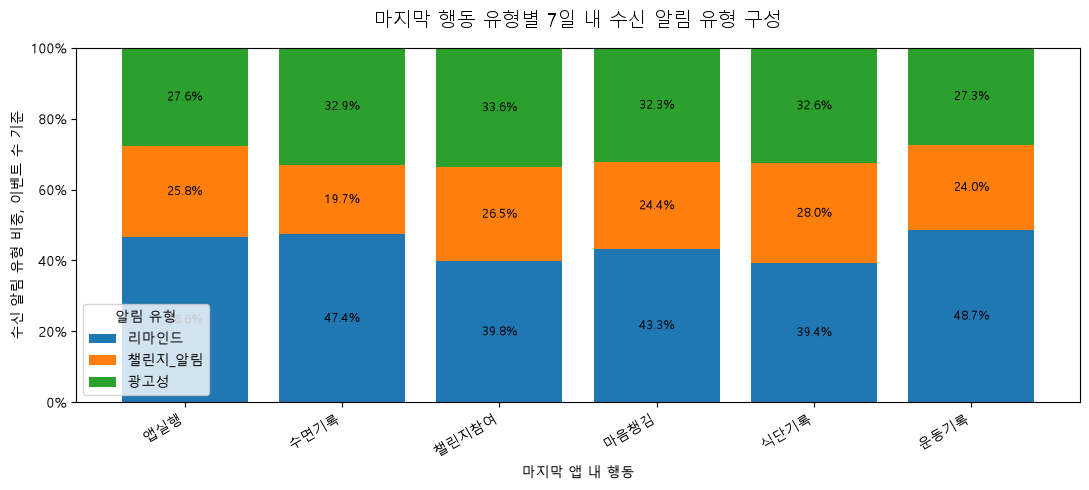

In [41]:
# =========================
# 수신 이벤트 수 기준 알림 유형 구성
# =========================

receive_event_mix = (
    noti_7d_by_last_action[
        noti_7d_by_last_action["event_type"] == NOTI_RECEIVE
    ]
    .groupby(["last_app_event_type", "notification_type"])
    .size()
    .rename("receive_event_count")
    .reset_index()
)

receive_event_mix = receive_event_mix.merge(
    last_action_denominator,
    on="last_app_event_type",
    how="left"
)

# 표본 작은 마지막 행동 유형 제외
receive_event_mix = receive_event_mix[
    receive_event_mix["last_action_user_count"] >= 100
].copy()

mix_pivot = (
    receive_event_mix
    .pivot_table(
        index="last_app_event_type",
        columns="notification_type",
        values="receive_event_count",
        aggfunc="sum",
        fill_value=0
    )
    .reindex(index=action_order, columns=noti_order)
    .fillna(0)
)

mix_share = mix_pivot.div(mix_pivot.sum(axis=1), axis=0).fillna(0)

x = np.arange(len(mix_share.index))
bottom = np.zeros(len(mix_share))

plt.figure(figsize=(11, 5))

for noti_type in noti_order:
    values = mix_share[noti_type].values
    plt.bar(
        x,
        values,
        bottom=bottom,
        label=noti_type
    )

    for idx, value in enumerate(values):
        if value >= 0.05:
            plt.text(
                idx,
                bottom[idx] + value / 2,
                f"{value*100:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

    bottom += values

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.title("마지막 행동 유형별 7일 내 수신 알림 유형 구성", fontsize=14, pad=15)
plt.xlabel("마지막 앱 내 행동")
plt.ylabel("수신 알림 유형 비중, 이벤트 수 기준")

plt.xticks(x, mix_share.index, rotation=30, ha="right")
plt.legend(title="알림 유형")

plt.ylim(0, 1)
plt.tight_layout()
plt.show()